In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, tqdm, glob
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

import jax
import jax.numpy as jnp
import jax_cosmo as jc

import optax
from flax import nnx
import orbax.checkpoint as ocp

import diffrax
from diffrax import diffeqsolve, ODETerm, Dopri5, LeapfrogMidpoint, PIDController, SaveAt, ConstantStepSize
from jax.experimental.ode import odeint

import jaxpm
from jaxpm.painting import cic_paint, cic_read
from jaxpm.pm import linear_field, lpt, make_ode_fn, pm_forces, make_ode_fn_diffrax, make_ode_fn
from jaxpm.kernels import fftk, gradient_kernel, invlaplace_kernel, longrange_kernel, invnabla_kernel
from jaxpm import camels, plotting, hpm, pm, nn

jax.devices("gpu")

[cuda(id=0)]

In [3]:
parts_per_dim = 64
mesh_per_dim = parts_per_dim
mesh_shape = [mesh_per_dim] * 3
box_size = [float(mesh_per_dim)] * 3

In [4]:
CV = "CV_0"
i_snapshots = range(1, 33+8, 8)

In [5]:
nbody_dict = camels.load_CV_snapshots(
    "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG_DM/CV/" + CV,
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
    return_hydro=False
)

cosmo = nbody_dict["cosmo"]
scales = nbody_dict["scales"]

n_dm_poss = nbody_dict["dm_poss"]
n_dm_vels = nbody_dict["dm_vels"]

Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG_DM/CV/CV_0/snapshot_018.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG_DM/CV/CV_0/snapshot_042.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG_DM/CV/CV_0/snapshot_058.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG_DM/CV/CV_0/snapshot_074.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG_DM/CV/CV_0/snapshot_090.hdf5']
Selecting 262144 dark matter (deterministic)


loading snapshots: 100%|██████████| 5/5 [00:17<00:00,  3.57s/it]


In [6]:
hydro_dict = camels.load_CV_snapshots(
    "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/" + CV,
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
    return_hydro=True,
)

h_cosmo = hydro_dict["cosmo"]
h_scales = hydro_dict["scales"]

h_dm_poss = hydro_dict["dm_poss"]
h_dm_vels = hydro_dict["dm_vels"]
h_gas_poss = hydro_dict["gas_poss"]
h_gas_vels = hydro_dict["gas_vels"]

h_dm_mass = cosmo.Omega_c / (cosmo.Omega_c + cosmo.Omega_b)
h_gas_mass = cosmo.Omega_b / (cosmo.Omega_c + cosmo.Omega_b)

Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_018.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_042.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_058.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_074.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_090.hdf5']
Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


loading snapshots: 100%|██████████| 5/5 [00:54<00:00, 10.91s/it]


In [7]:
vcic_paint = jax.vmap(cic_paint, in_axes=(None, 0))

n_N_dm = vcic_paint(jnp.zeros(mesh_shape), n_dm_poss)
n_rho_dm = n_N_dm

h_N_dm = vcic_paint(jnp.zeros(mesh_shape), h_dm_poss)
h_N_gas = vcic_paint(jnp.zeros(mesh_shape), h_gas_poss)
h_rho_dm = h_dm_mass * h_N_dm
h_rho_gas = h_gas_mass * h_N_gas
h_rho_tot = h_rho_dm + h_rho_gas

100%|██████████| 5/5 [00:10<00:00,  2.07s/it]


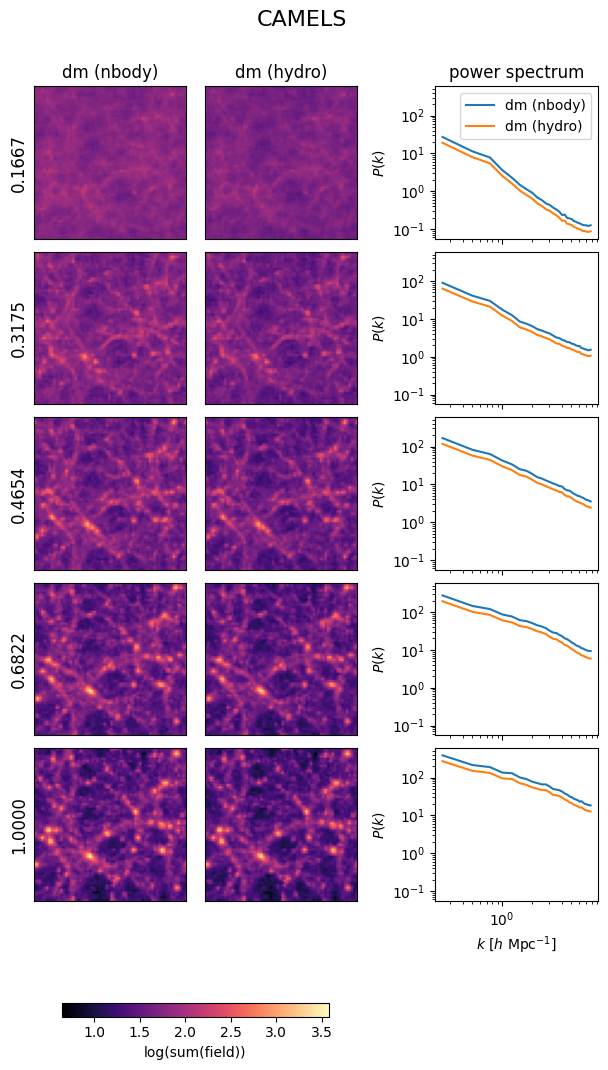

In [32]:
plotting.compare_field_evolution(
    scales, 
    jnp.stack([n_rho_dm, h_rho_dm], axis=0),
    # jnp.stack([n_rho_dm, h_rho_tot], axis=0),
    title="CAMELS",
    col_titles=["dm (nbody)", "dm (hydro)"],
    # col_titles=["dm (nbody)", "gas + dm (hydro)"],
    include_pk=True,
)

100%|██████████| 5/5 [00:20<00:00,  4.12s/it]


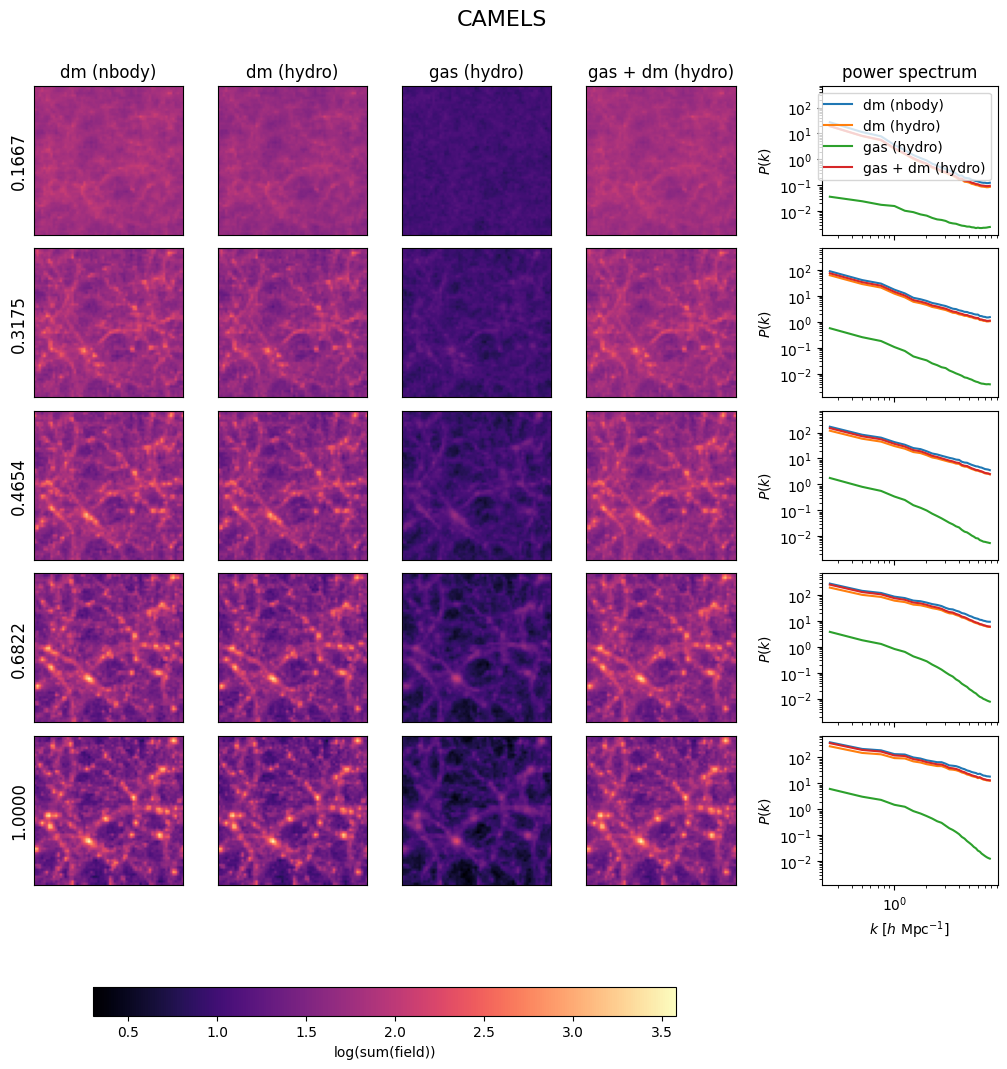

In [19]:
plotting.compare_field_evolution(
    scales, 
    jnp.stack([n_rho_dm, h_rho_dm, h_rho_gas, h_rho_tot], axis=0),
    title="CAMELS",
    col_titles=["dm (nbody)", "dm (hydro)", "gas (hydro)", "gas + dm (hydro)"],
    include_pk=True,
)

100%|██████████| 5/5 [00:15<00:00,  3.09s/it]


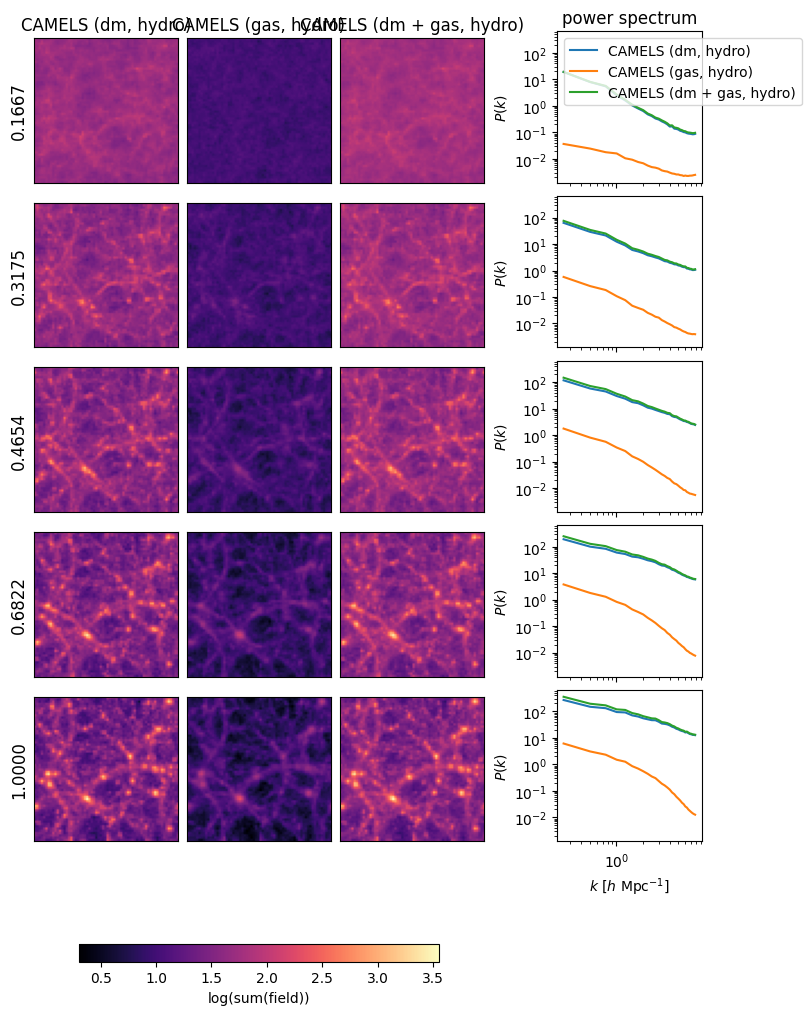

In [45]:
plotting.compare_field_evolution(
    scales, 
    jnp.stack([h_rho_dm, h_rho_gas, h_rho_tot], axis=0),
    col_titles=["CAMELS (dm, hydro)", "CAMELS (gas, hydro)", "CAMELS (dm + gas, hydro)"],
    include_pk=True,
)

In [9]:
# plotting.compare_particle_evolution(
#     mesh_shape, 
#     scales, 
#     jnp.stack([n_dm_poss, h_dm_poss], axis=0), 
#     title="gas",
#     col_titles=["CAMELS (dm, nbody)", "CAMELS (dm, hydro)"],
#     include_pk=True,
# )

# gravity only

### dark matter (vannila JaxPM -> "PM")

In [10]:
n_pm_ode = pm.make_ode_fn_diffrax(cosmo, mesh_shape)

res = diffeqsolve(
        terms=ODETerm(n_pm_ode),
        solver=LeapfrogMidpoint(),
        t0=scales[0],
        t1=scales[-1],
        dt0=0.01,
        y0=jnp.stack([n_dm_poss[0], n_dm_vels[0]]),
        saveat=SaveAt(ts=scales),
        max_steps=100,
        stepsize_controller=ConstantStepSize(),
)
res = res.ys
res = jnp.transpose(res, (1,0,2,3))

n_pm_dm_poss, n_pm_dm_vels = res

In [11]:
n_pm_N_dm = vcic_paint(jnp.zeros(mesh_shape), n_pm_dm_poss)
n_pm_rho_dm = n_pm_N_dm

100%|██████████| 5/5 [00:10<00:00,  2.11s/it]


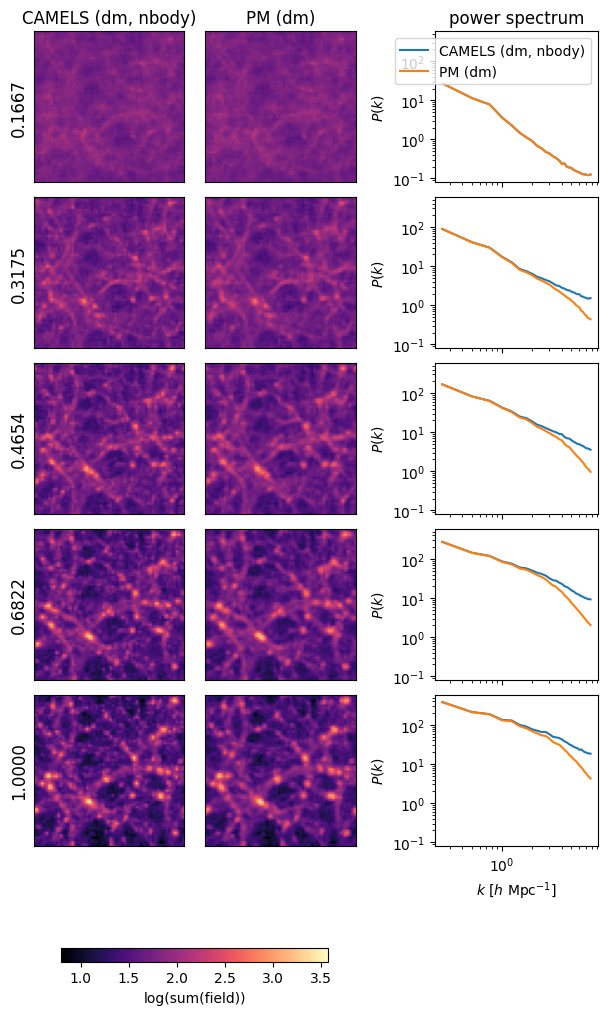

In [12]:
plotting.compare_field_evolution(
    scales, 
    jnp.stack([n_rho_dm, n_pm_rho_dm], axis=0),
    # jnp.stack([n_rho_dm, h_rho_tot], axis=0),
    col_titles=["CAMELS (dm, nbody)", "PM (dm)"],
    # col_titles=["dm (nbody)", "gas + dm (hydro)"],
    include_pk=True,
)

In [13]:
# plotting.compare_particle_evolution(
#     mesh_shape, 
#     scales, 
#     jnp.stack([n_dm_poss, n_pm_dm_poss], axis=0), 
#     title="gas",
#     col_titles=["CAMELS", "gravity (dm)"],
#     include_pk=True,
# )

### dark matter + gas particles ("HPM" extension)

In [41]:
h_pm_ode = hpm.get_hpm_network_ode_fn(None, mesh_shape, h_cosmo, gravity_only=True, integrator_type="diffrax")

res = diffeqsolve(
        terms=ODETerm(h_pm_ode),
        solver=LeapfrogMidpoint(),
        t0=scales[0],
        t1=scales[-1],
        dt0=0.01,
        y0=(h_dm_poss[0], h_dm_vels[0], h_gas_poss[0], h_gas_vels[0]),
        saveat=SaveAt(ts=scales),
        max_steps=100,
        stepsize_controller=ConstantStepSize(),
)
res = res.ys

h_pm_dm_poss, h_pm_dm_vels, h_pm_gas_poss, h_pm_gas_vels = res

In [42]:
h_pm_N_dm = vcic_paint(jnp.zeros(mesh_shape), h_pm_dm_poss)
h_pm_N_gas = vcic_paint(jnp.zeros(mesh_shape), h_pm_gas_poss)
h_pm_rho_dm = h_dm_mass * h_pm_N_dm
h_pm_rho_gas = h_gas_mass * h_pm_N_gas
h_pm_rho_tot = h_pm_rho_dm + h_pm_rho_gas

100%|██████████| 5/5 [00:10<00:00,  2.01s/it]


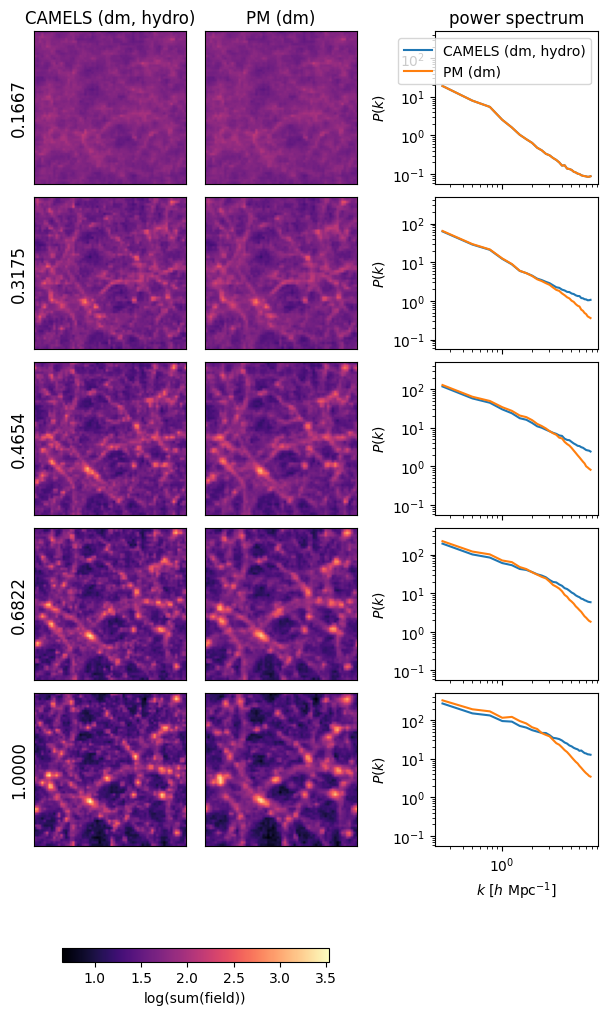

In [43]:
plotting.compare_field_evolution(
    scales, 
    jnp.stack([h_rho_dm, h_pm_rho_dm], axis=0),
    # jnp.stack([n_rho_dm, h_rho_tot], axis=0),
    col_titles=["CAMELS (dm, hydro)", "PM (dm)"],
    # col_titles=["dm (nbody)", "gas + dm (hydro)"],
    include_pk=True,
)

100%|██████████| 5/5 [00:20<00:00,  4.02s/it]


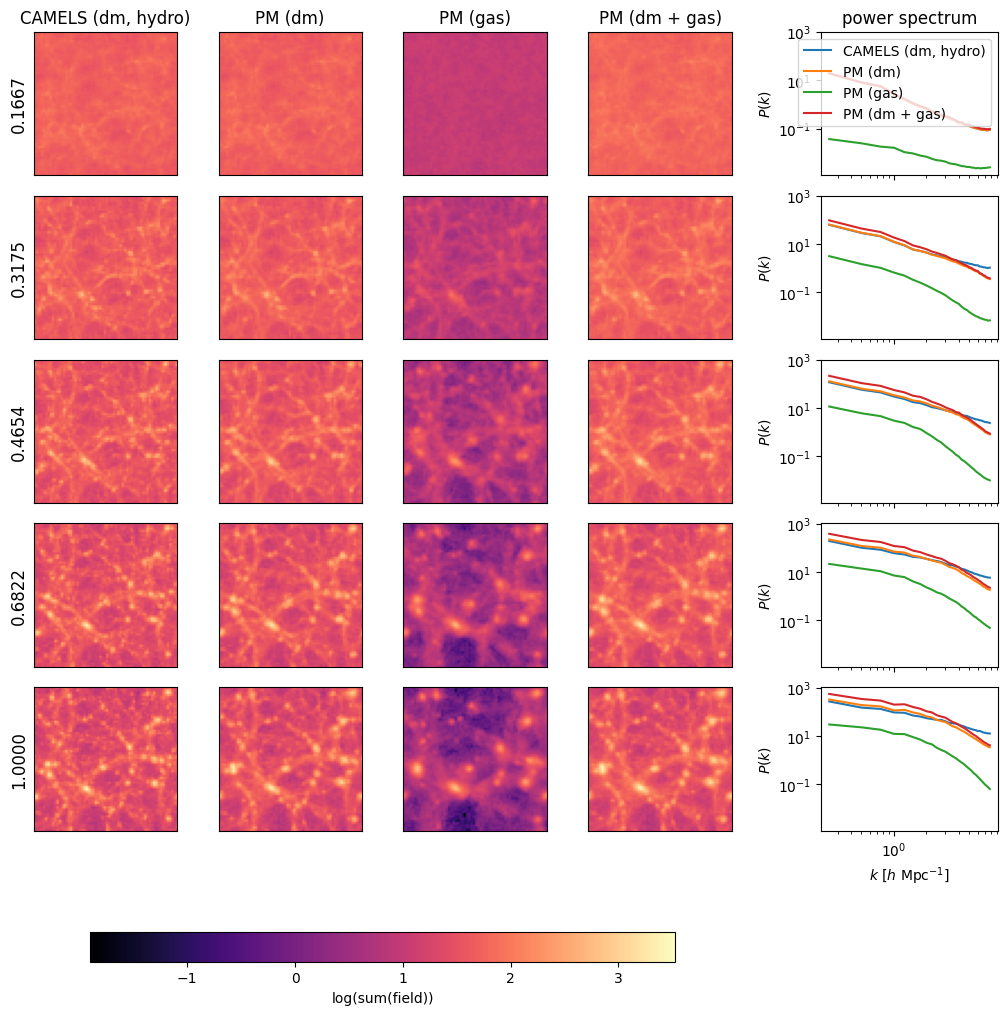

In [44]:
plotting.compare_field_evolution(
    scales, 
    jnp.stack([h_rho_dm, h_pm_rho_dm, h_pm_rho_gas, h_pm_rho_tot], axis=0),
    # jnp.stack([n_rho_dm, h_rho_tot], axis=0),
    col_titles=["CAMELS (dm, hydro)", "PM (dm)", "PM (gas)", "PM (dm + gas)"],
    # col_titles=["dm (nbody)", "gas + dm (hydro)"],
    include_pk=True,
)

In [17]:
# plotting.compare_particle_evolution(
#     mesh_shape, 
#     scales, 
#     jnp.stack([h_dm_poss, h_pm_gas_poss], axis=0), 
#     title="gas",
#     col_titles=["CAMELS", "gravity (dm + gas)"],
#     include_pk=True,
# )